## Notebook 01 - EDA and Data Preparation
### Used Car Residual Value Model
**Data**: `car_data.csv` - 26,157 transactions (2017–2020)

In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Imports libraries
import warnings
import pandas as pd
import sys; sys.path.insert(0, "..")

from src.data_ead import clean_and_engineer, print_data_summary
from src.plot_function import plot_eda

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 30)
warnings.simplefilter(action = "ignore", category = pd.errors.PerformanceWarning)

In [3]:
# Load Data
df = pd.read_csv(
    "../data/raw/car_data.csv"
)

# Show table
df.head(5)

,contract_date,sold_date,car_price,sold_price,down_percent,model_year,color,condition,km,car_model,wheel,transmission,door,engine,fuel
0,2013-03-04,2017-09-01,734000,361660,0.100,2013,NaN,Fair,101814,Yaris,FWD,Automatic,5,1.500,Benzene
1,2014-07-21,2017-09-01,669000,251450,0.029,2010,NaN,Fair,260327,C-Cab,RWD,Manual,2,2.500,Diesel
2,2016-04-29,2017-09-01,562000,383060,0.001,2016,NaN,Fair,12312,B-Cab,RWD,Manual,2,2.400,Diesel
3,2014-05-12,2017-09-01,740000,410880,0.251,2013,NaN,Fair,70534,D-Cab,RWD,Manual,4,2.500,Diesel
4,2016-06-03,2017-09-01,635000,357380,0.201,2016,NaN,Fair,53920,B-Cab,RWD,Manual,2,2.800,Diesel


In [4]:
# Clean and engineer features
df = clean_and_engineer(df)

# Show table
print(f"Clean shape: {df.shape}")
df.head(5)

Clean shape: (26104, 24)


,contract_date,sold_date,car_price,sold_price,down_percent,model_year,color,condition,km,car_model,wheel,transmission,door,engine,fuel,rvr,age_months,age_band,km_per_month,sell_year,sell_month,model_age,brand_tier,segment
0,2013-03-04,2017-09-01,734000,361660,0.100,2013,Unknown,Fair,101814.000,Yaris,FWD,Automatic,5,1.500,Benzene,0.493,53,48m+,1921.000,2017,9,4,standard,standard_Benzene
1,2014-07-21,2017-09-01,669000,251450,0.029,2010,Unknown,Fair,260327.000,C-Cab,RWD,Manual,2,2.500,Diesel,0.376,37,37-48m,7035.900,2017,9,7,pickup,pickup_Diesel
2,2016-04-29,2017-09-01,562000,383060,0.001,2016,Unknown,Fair,12312.000,B-Cab,RWD,Manual,2,2.400,Diesel,0.682,16,13-24m,769.500,2017,9,1,pickup,pickup_Diesel
3,2014-05-12,2017-09-01,740000,410880,0.251,2013,Unknown,Fair,70534.000,D-Cab,RWD,Manual,4,2.500,Diesel,0.555,39,37-48m,1808.600,2017,9,4,pickup,pickup_Diesel
4,2016-06-03,2017-09-01,635000,357380,0.201,2016,Unknown,Fair,53920.000,B-Cab,RWD,Manual,2,2.800,Diesel,0.563,14,13-24m,3851.400,2017,9,1,pickup,pickup_Diesel


In [5]:
# Print data summary and get recommended distribution
summary = print_data_summary(df)

Data summary
Rows after cleaning           : 26,104
RVR Mean                      : 0.5469
RVR STD                       : 0.1291
Skewness                      : -0.7082
Excess kurtosis               : 0.5564
Shapiro-Wilk                  : 0.0
Recommended dist              : Laplace


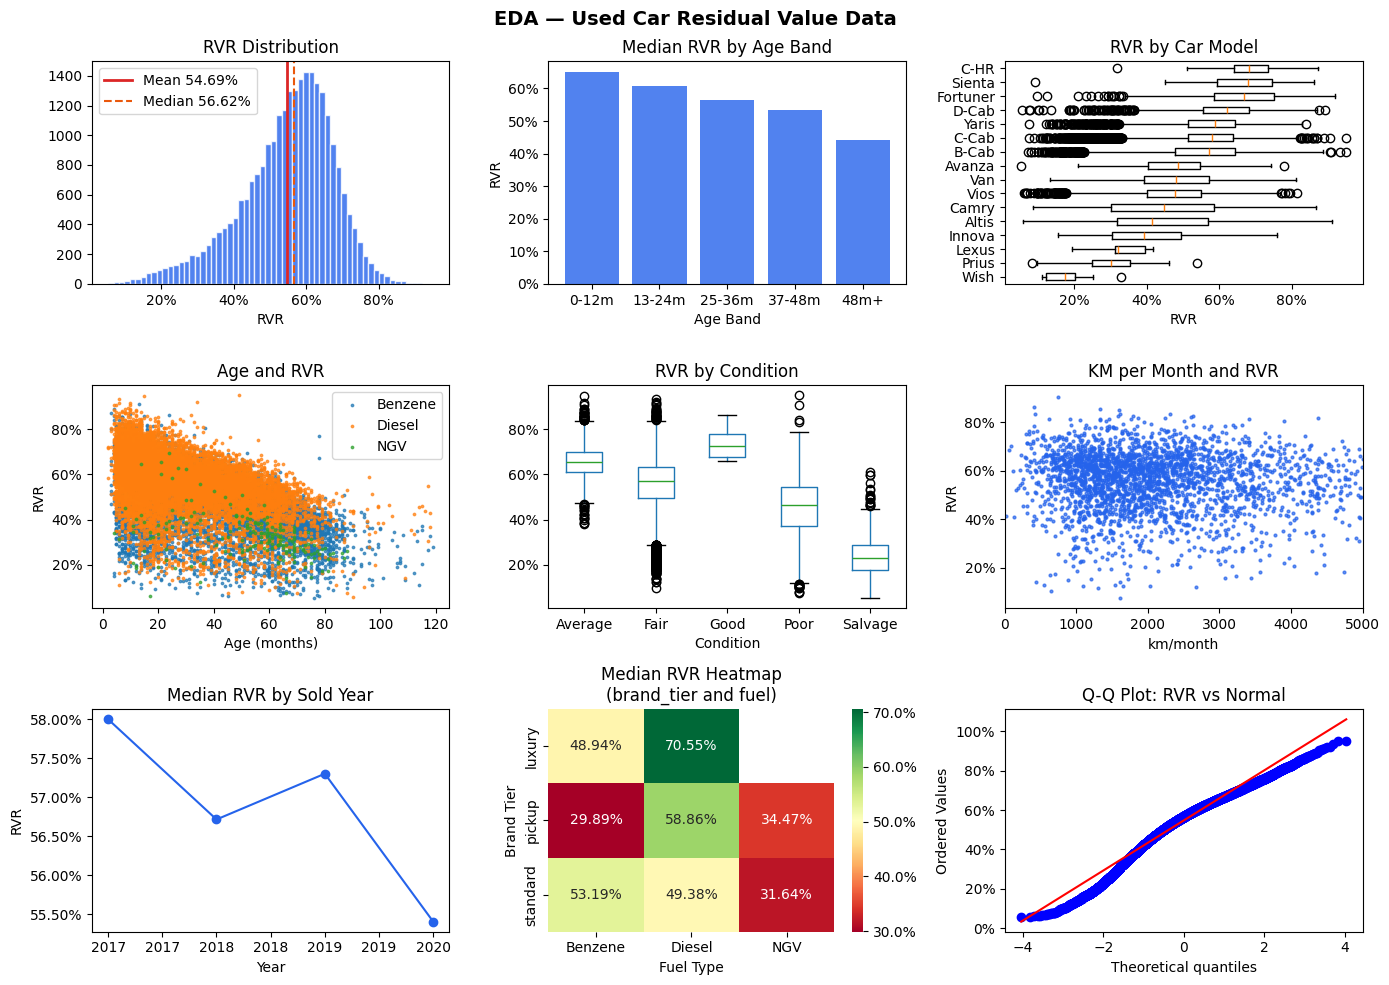

In [6]:
# EDA plots
plot_eda(df)

In [7]:
# Export
df.to_parquet(
    "../data/processed/car_data.parquet",
    engine = "pyarrow"
)